<a href="https://colab.research.google.com/github/koushik-ace/NLP/blob/main/2403A52258_NLP_Assignment_10_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 64.1 MB/s eta 0:00:00


In [ ]:
# ================================
# Loading Pre-trained Embeddings
# ================================
from gensim.models import KeyedVectors
import gensim.downloader as api

# ================================
# Handling Matrices & Numerical Operations
# ================================
import numpy as np

# ================================
# Visualization
# ================================
import matplotlib.pyplot as plt

# ================================
# t-SNE for Dimensionality Reduction
# ================================
from sklearn.manifold import TSNE

In [ ]:
# Load pre-trained Word2Vec model (may take time on first download)
model_word2vec = api.load("word2vec-google-news-300")
model_glove = api.load("glove-wiki-gigaword-100")

[==================================================] 100.0% 1662.8/1662.8MB downloaded
[==================================================] 100.0% 128.1/128.1MB downloaded


In [ ]:
word_list = [

    # Mythology
    "zeus", "hera", "apollo", "athena", "poseidon",

    # Transportation (modern)
    "airplane", "helicopter", "subway", "scooter", "ship",

    # Fruits
    "apple", "banana", "orange", "grape", "mango",

    # Programming
    "python", "java", "csharp", "javascript", "golang",

    # Weather
    "rain", "snow", "storm", "cloud", "wind",

    # Landmarks
    "pyramids", "eiffel", "colosseum", "tajmahal", "statueofliberty",

    # Occupations
    "lawyer", "farmer", "soldier", "writer", "actor",

    # Emotions (expanded)
    "fear", "joy", "trust", "disgust", "surprise"
]

In [ ]:
filtered_word_list_word2vec = []
vectors = []
for word in word_list:
    if word in model_word2vec:
        vectors.append(model_word2vec[word])
        filtered_word_list_word2vec.append(word)

# Convert to NumPy array
vectors_word2vec = np.array(vectors)

print("Total selected words:", len(word_list))
print("Words successfully vectorized (Word2Vec):", len(filtered_word_list_word2vec))
print("Vector shape:", vectors_word2vec.shape)
print(vectors_word2vec[0])

Total selected words: 40
Words successfully vectorized (Word2Vec): 31
Vector shape: (31, 300)
[-1.48925781e-02  1.68945312e-01 -3.19824219e-02  3.26171875e-01
  1.22558594e-01  2.03125000e-01  9.91210938e-02 -1.46484375e-01
  4.22363281e-02 -3.39355469e-02 -9.76562500e-02 -9.57031250e-02
 -1.15722656e-01  3.41796875e-02 -1.34277344e-02  7.32421875e-02
 -7.17773438e-02  1.95312500e-01  4.39453125e-02 -1.23535156e-01
 -7.56835938e-02 -1.37695312e-01 -8.44726562e-02 -4.00390625e-02
 -2.79296875e-01  1.83105469e-02 -2.13867188e-01  2.44140625e-01
  9.17968750e-02 -1.63085938e-01 -1.18164062e-01  1.04492188e-01
 -1.64062500e-01  2.87109375e-01 -1.52343750e-01 -1.71875000e-01
 -1.35742188e-01 -1.74804688e-01  1.46484375e-01 -1.78710938e-01
  1.23046875e-01  6.17675781e-02  3.06640625e-01  1.86523438e-01
  8.34960938e-02  4.10156250e-02  1.68457031e-02 -1.64062500e-01
  9.22851562e-02 -2.48046875e-01  1.22680664e-02  7.17773438e-02
 -8.97216797e-03  1.59912109e-02 -1.25976562e-01  6.68945312e

In [ ]:
filtered_word_list_glove = []
vectors = []
for word in word_list:
    if word in model_glove:
        vectors.append(model_glove[word])
        filtered_word_list_glove.append(word)

# Convert to NumPy array
vectors_glove = np.array(vectors)

print("Total selected words:", len(word_list))
print("Words successfully vectorized (GloVe):", len(filtered_word_list_glove))
print("Vector shape:", vectors_glove.shape)
print(vectors_glove[0])

Total selected words: 40
Words successfully vectorized (GloVe): 36
Vector shape: (36, 100)
[ 2.1534e-01  4.6497e-01  3.4684e-01  3.6058e-01 -6.1938e-01  7.1045e-01
 -5.2483e-01 -6.8764e-01  2.4996e-01 -2.4169e-01  2.5155e-01  4.1229e-01
  8.5005e-01  6.0297e-01 -2.0636e-01 -9.2409e-01  7.7317e-02  1.0427e+00
 -7.6307e-01  6.9264e-01 -9.2247e-01 -1.2863e+00 -8.6955e-01  1.2029e+00
  5.4891e-01  4.4451e-01 -1.3946e+00  1.3148e-01 -3.4692e-01  2.7659e-01
  4.8882e-01 -6.5474e-02 -5.8949e-01  9.6504e-01  1.6484e-01 -1.5887e-01
  1.4522e-02  5.1853e-01  3.7734e-01 -5.5546e-01  5.1987e-04  9.1871e-01
 -4.0175e-02 -5.4081e-01 -7.0852e-02  2.7819e-02 -1.4158e-01  3.7013e-01
  3.7487e-01  6.2157e-01 -3.8152e-01  6.5442e-01  1.1006e+00  4.7546e-01
 -4.1251e-01 -5.5896e-01  1.3095e-01  5.0395e-01 -5.8674e-01 -1.1780e-01
  4.1186e-01  4.2969e-01  8.8820e-02  9.7766e-01 -3.4508e-01  9.7668e-02
  5.0565e-02  1.4744e-01 -1.2164e-01  1.5274e-01 -1.5637e-01 -3.3758e-01
 -2.3638e-01  9.8969e-02 -8.1935e

In [ ]:
# Assume vectors already extracted from previous step
# vectors shape example: (40, 100)

# Apply t-SNE
tsne = TSNE(
    n_components=2,      # Reduce to 2D
    random_state=42,
    perplexity=10,
    learning_rate=200
)

tsne_coordinates = tsne.fit_transform(vectors_word2vec)

# Store results
print("Original Shape:", vectors_word2vec.shape)
print("Reduced Shape:", tsne_coordinates.shape)

# Display first 5 coordinates
print("\nFirst 5 t-SNE Coordinates:")
print(tsne_coordinates[:5])
# Display first 5 coordinates of word2vec
print("\nFirst 5 t-SNE Coordinates:")
print(vectors_word2vec[:5])

Original Shape: (31, 300)
Reduced Shape: (31, 2)

First 5 t-SNE Coordinates:
[[  -7.9002404  -60.21015  ]
 [  99.009476  -546.7212   ]
 [ 191.74246   -622.3425   ]
 [ -37.1566    -834.69635  ]
 [ -66.328064  -595.58124  ]]

First 5 t-SNE Coordinates:
[[-0.01489258  0.16894531 -0.03198242 ...  0.08447266 -0.07617188
  -0.08837891]
 [ 0.16894531 -0.20019531 -0.16113281 ...  0.16699219 -0.0123291
  -0.20410156]
 [-0.02050781 -0.08447266 -0.1875     ...  0.04614258 -0.00091171
  -0.26367188]
 [ 0.02819824 -0.22753906 -0.08007812 ...  0.2421875  -0.09033203
   0.08056641]
 [ 0.2890625  -0.04931641 -0.13085938 ...  0.13964844 -0.14257812
  -0.14648438]]


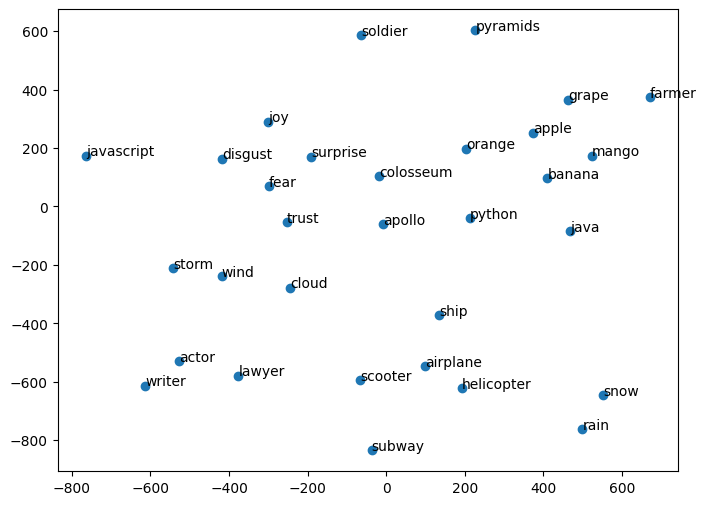

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(tsne_coordinates[:,0], tsne_coordinates[:,1])

for i, word in enumerate(filtered_word_list_word2vec):
    plt.annotate(word, (tsne_coordinates[i,0], tsne_coordinates[i,1]))

plt.show()

In [ ]:
# Assume vectors already extracted from previous step
# vectors shape example: (40, 100)

# Apply t-SNE
tsne = TSNE(
    n_components=2,      # Reduce to 2D
    random_state=42,
    perplexity=10,
    learning_rate=200
)

tsne_coordinates = tsne.fit_transform(vectors_glove)

# Store results
print("Original Shape:", vectors_glove.shape)
print("Reduced Shape:", tsne_coordinates.shape)

# Display first 5 coordinates
print("\nFirst 5 t-SNE Coordinates:")
print(tsne_coordinates[:5])
# Display first 5 coordinates of glove
print("\nFirst 5 t-SNE Coordinates:")
print(vectors_glove[:5])

Original Shape: (36, 100)
Reduced Shape: (36, 2)

First 5 t-SNE Coordinates:
[[-270.30865   152.68637 ]
 [-254.24207    76.458755]
 [-181.44994    20.10993 ]
 [-323.43942    88.00841 ]
 [-186.50676   135.33415 ]]

First 5 t-SNE Coordinates:
[[ 2.1534e-01  4.6497e-01  3.4684e-01  3.6058e-01 -6.1938e-01  7.1045e-01
  -5.2483e-01 -6.8764e-01  2.4996e-01 -2.4169e-01  2.5155e-01  4.1229e-01
   8.5005e-01  6.0297e-01 -2.0636e-01 -9.2409e-01  7.7317e-02  1.0427e+00
  -7.6307e-01  6.9264e-01 -9.2247e-01 -1.2863e+00 -8.6955e-01  1.2029e+00
   5.4891e-01  4.4451e-01 -1.3946e+00  1.3148e-01 -3.4692e-01  2.7659e-01
   4.8882e-01 -6.5474e-02 -5.8949e-01  9.6504e-01  1.6484e-01 -1.5887e-01
   1.4522e-02  5.1853e-01  3.7734e-01 -5.5546e-01  5.1987e-04  9.1871e-01
  -4.0175e-02 -5.4081e-01 -7.0852e-02  2.7819e-02 -1.4158e-01  3.7013e-01
   3.7487e-01  6.2157e-01 -3.8152e-01  6.5442e-01  1.1006e+00  4.7546e-01
  -4.1251e-01 -5.5896e-01  1.3095e-01  5.0395e-01 -5.8674e-01 -1.1780e-01
   4.1186e-01  4.29

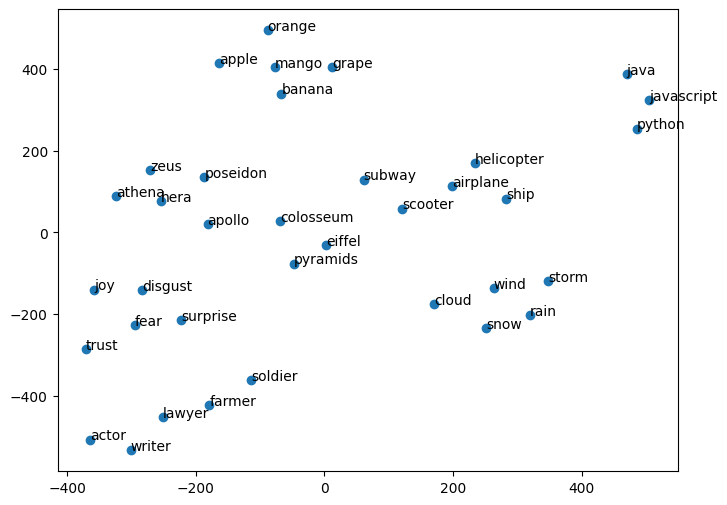

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(tsne_coordinates[:,0], tsne_coordinates[:,1])

for i, word in enumerate(filtered_word_list_glove):
    plt.annotate(word, (tsne_coordinates[i,0], tsne_coordinates[i,1]))

plt.show()